<a target="_blank" href="https://colab.research.google.com/github/tabt/geo_notebooks/blob/main/dust3r_pointmap.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Point maps from multiple photos with DUSt3R

## 1. Packages

In [2]:
!git clone --recursive https://github.com/naver/dust3r
%cd dust3r
!pip install -q -r requirements.txt
!pip install -q -r requirements_optional.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.8 MB/s eta 0:00:00


## 2. Config

In [27]:
import os
import numpy as np
import torch

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE   = 512

CONF_THR = 3.0  # порог confidence при отборе точек
OUT_DIR  = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print("device:", DEVICE)

device: cuda


## 3. Load model

In [4]:
# без этого блока не работают локальные импорты из dust3r
import sys

sys.path.insert(0, '/content/dust3r')

for m in list(sys.modules):
    if m == 'dust3r' or m.startswith('dust3r.'):
        del sys.modules[m]

In [ ]:
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

CKPT = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(CKPT).to(DEVICE)

model.eval()

## 4. Images loading

In [8]:
!mkdir ../frames

--- загрузить фото в папку frames ---

In [9]:
images = load_images('/content/frames/', size=IMG_SIZE, verbose=True)
for i, im in enumerate(images):
    print(f"view {i}: img {tuple(im['img'].shape)}  true_shape {im['true_shape'].tolist()}")

H, W = images[0]["true_shape"][0].tolist()
print("point map resolution:", H, "x", W)

>> Loading images from /content/frames/
 - adding photo_1_2026-07-24_16-32-30.jpg with resolution 960x1280 --> 384x512
 - adding photo_2_2026-07-24_16-32-30.jpg with resolution 960x1280 --> 384x512
 - adding photo_3_2026-07-24_16-32-30.jpg with resolution 960x1280 --> 384x512
 - adding photo_4_2026-07-24_16-32-30.jpg with resolution 960x1280 --> 384x512
 - adding photo_5_2026-07-24_16-32-30.jpg with resolution 960x1280 --> 384x512
 (Found 5 images)
view 0: img (1, 3, 512, 384)  true_shape [[512, 384]]
view 1: img (1, 3, 512, 384)  true_shape [[512, 384]]
view 2: img (1, 3, 512, 384)  true_shape [[512, 384]]
view 3: img (1, 3, 512, 384)  true_shape [[512, 384]]
view 4: img (1, 3, 512, 384)  true_shape [[512, 384]]
point map resolution: 512 x 384


## 5. Inference

In [10]:
pairs = make_pairs(images, scene_graph="complete", prefilter=None, symmetrize=True)
output = inference(pairs, model, DEVICE, batch_size=1, verbose=True)

pred1, pred2 = output["pred1"], output["pred2"]
view1, view2 = output["view1"], output["view2"]

pts3d_1_raw = pred1["pts3d"][0]                    # (H, W, 3)
pts3d_2_raw = pred2["pts3d_in_other_view"][0]      # (H, W, 3)
conf_1_raw  = pred1["conf"][0]                     # (H, W)
conf_2_raw  = pred2["conf"][0]                     # (H, W)

print("pts3d view1:", tuple(pts3d_1_raw.shape), "| conf:", tuple(conf_1_raw.shape))
print("pts3d view2:", tuple(pts3d_2_raw.shape))

>> Inference with model on 20 image pairs


  0%|          | 0/20 [00:00<?, ?it/s]/content/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/content/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/content/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 20/20 [00:13<00:00,  1.48it/s]

pts3d view1: (512, 384, 3) | conf: (512, 384)
pts3d view2: (512, 384, 3)


## 6. Global alignment

In [11]:
scene = None

mode = GlobalAlignerMode.PointCloudOptimizer   # или GlobalAlignerMode.PairViewer
scene = global_aligner(output, device=DEVICE, mode=mode)

if mode == GlobalAlignerMode.PointCloudOptimizer:
    loss = scene.compute_global_alignment(
        init="mst", niter=300, schedule="cosine", lr=0.01
    )
    print("\nfinal alignment loss:", float(loss))

imgs        = scene.imgs
focals      = scene.get_focals()
poses       = scene.get_im_poses()
pts3d       = scene.get_pts3d()
conf_masks  = scene.get_masks()

print("focals:", [round(float(f), 1) for f in focals])
print("pts3d[0]:", tuple(pts3d[0].shape), "| pts3d[1]:", tuple(pts3d[1].shape))

 init edge (4*,1*) score=np.float64(7.988563060760498)
 init edge (0*,1) score=np.float64(6.289315700531006)
 init edge (3*,1) score=np.float64(5.891087532043457)
 init edge (2*,3) score=np.float64(6.157006740570068)
 init loss = 0.00850603450089693
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


  0%|          | 0/300 [00:00<?, ?it/s]/content/dust3r/dust3r/cloud_opt/base_opt.py:366: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(loss), lr
100%|██████████| 300/300 [00:22<00:00, 13.52it/s, lr=1.27413e-06 loss=0.002607]


final alignment loss: 0.002607000060379505
focals: [475.5, 514.0, 493.1, 488.6, 482.6]
pts3d[0]: (512, 384, 3) | pts3d[1]: (512, 384, 3)


## 7. Visualize

In [ ]:
# облако точек
from IPython.display import display

display(scene.show().scene.show())

found 18547 matches


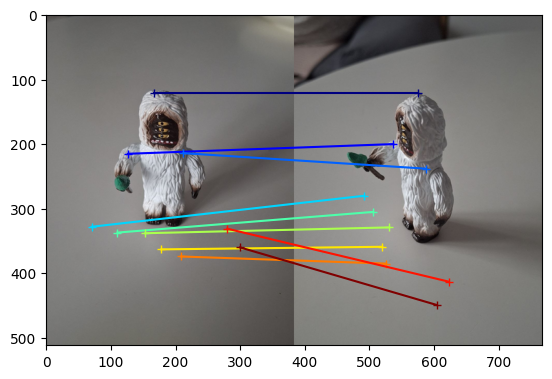

In [20]:
# отрисовка сматчившихся точек на паре фото
from dust3r.utils.geometry import find_reciprocal_matches, xy_grid

pts2d_list, pts3d_list = [], []
for i in range(2):
    conf_i = conf_masks[i].cpu().numpy()
    pts2d_list.append(xy_grid(*imgs[i].shape[:2][::-1])[conf_i])  # imgs[i].shape[:2] = (H, W)
    pts3d_list.append(pts3d[i].detach().cpu().numpy()[conf_i])
reciprocal_in_P2, nn2_in_P1, num_matches = find_reciprocal_matches(*pts3d_list)
print(f'found {num_matches} matches')
matches_im1 = pts2d_list[1][reciprocal_in_P2]
matches_im0 = pts2d_list[0][nn2_in_P1][reciprocal_in_P2]

import numpy as np
from matplotlib import pyplot as pl
n_viz = 10
match_idx_to_viz = np.round(np.linspace(0, num_matches-1, n_viz)).astype(int)
viz_matches_im0, viz_matches_im1 = matches_im0[match_idx_to_viz], matches_im1[match_idx_to_viz]

H0, W0, H1, W1 = *imgs[0].shape[:2], *imgs[1].shape[:2]
img0 = np.pad(imgs[0], ((0, max(H1 - H0, 0)), (0, 0), (0, 0)), 'constant', constant_values=0)
img1 = np.pad(imgs[1], ((0, max(H0 - H1, 0)), (0, 0), (0, 0)), 'constant', constant_values=0)
img = np.concatenate((img0, img1), axis=1)
pl.figure()
pl.imshow(img)
cmap = pl.get_cmap('jet')
for i in range(n_viz):
    (x0, y0), (x1, y1) = viz_matches_im0[i].T, viz_matches_im1[i].T
    pl.plot([x0, x1 + W0], [y0, y1], '-+', color=cmap(i / (n_viz - 1)), scalex=False, scaley=False)
pl.show(block=True)

## 8. Export (.ply)

In [37]:
import os
import numpy as np


def to_np(x):
    return x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)


def write_ply(path, pts, col=None):
    """Бинарный PLY"""
    pts = np.asarray(pts, dtype=np.float32).reshape(-1, 3)
    n = len(pts)
    has_col = col is not None and len(col) == n
    if has_col:
        col = np.asarray(col)
        if col.dtype != np.uint8:
            col = (np.clip(col, 0, 1) * 255).astype(np.uint8)
        col = col.reshape(-1, 3)

    header = ["ply", "format binary_little_endian 1.0", f"element vertex {n}",
              "property float x", "property float y", "property float z"]
    if has_col:
        header += ["property uchar red", "property uchar green", "property uchar blue"]

    with open(path, "wb") as f:
        f.write(("\n".join(header + ["end_header", ""])).encode())
        dt = [("x", "<f4"), ("y", "<f4"), ("z", "<f4")]
        if has_col:
            dt += [("red", "u1"), ("green", "u1"), ("blue", "u1")]
        arr = np.empty(n, dtype=dt)
        arr["x"], arr["y"], arr["z"] = pts.T
        if has_col:
            arr["red"], arr["green"], arr["blue"] = col.T
        arr.tofile(f)
    print("saved:", path, "|", n, "точек")


P, C = [], []
for p, m, im in zip(pts3d, conf_masks, imgs):
    p, m, im = to_np(p).reshape(-1, 3), to_np(m).reshape(-1), np.asarray(im).reshape(-1, 3)
    P.append(p[m])
    C.append(im[m])

scene_pts = np.concatenate(P)
scene_col = np.concatenate(C)
print(f"видов: {len(P)} | точек после фильтра conf: {len(scene_pts)}")

write_ply(os.path.join(OUT_DIR, "scene.ply"), scene_pts, scene_col)

видов: 5 | точек после фильтра conf: 310936
saved: ../outputs/scene.ply | 310936 точек
